-합성곱 신경망 CNN

픽셀 정보 그대로 학습 시 그냥 하나의 완전한 이미지를 형성하는지 모르기 때문에, 원본 이미지에서 강아지의 특징이 사라지게 된다. cnn은 이미지 공간정보를 유지한 채로 학습이 가능한 방식. 
 파라미터 공유 (Parameter Sharing): 이미지의 한 부분에서 학습한 필터를 다른 부분에도 똑같이 적용하므로, 학습해야 할 변수의 수가 줄어들어 효율적
 공간 구조 유지: 픽셀 사이의 인접성을 파괴하지 않고 데이터의 특징을 효율적  


---


-CNN 전체 구조
 이미지의 2차원 구조를 유지한 채 주변 픽셀 관계와 시각적 특징을 학습함. 일반적인 신경망은 이미지를 처리할 때 2차원 이미지를 1차원 줄글 형태로 길게 펼쳐서 입력함. 이 과정에서 "어떤 픽셀이 어떤 픽셀 옆에 있는지"와 같은 공간 정보가 완전히 파괴됨. 
 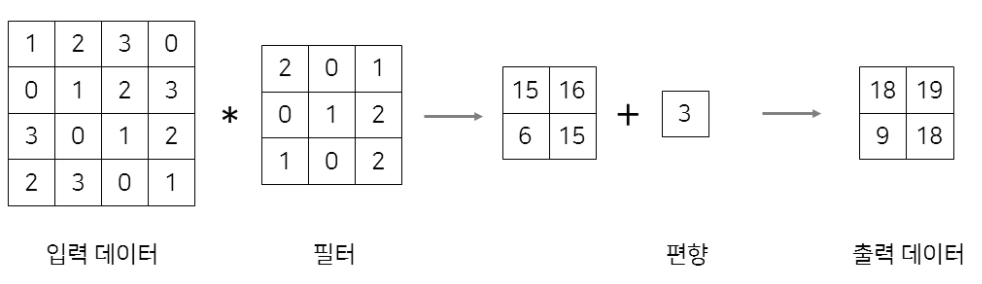

CNN의 방식: 이미지를 있는 그대로의 행렬 형태로 입력받아 처리하므로, 픽셀 간의 연관성과 패턴을 효과적으로 유지함. 
특징 추출, 차원 축소, 특정한 특징이 존재하는가. 

특징 추출후 평면화 시키기 때문에 손실의 정도가 훨씬 낫다. 

-CNN 모델

특징 추출 (Feature Learning) - Convolution, Pooling이 담당
    *Convolution Layer* : 전체 이미지를 일정 크기의 필터로 훑으며 이미지의 특징을 학습. 필터가 이미지 위를 슬라이딩하고 각 위치에서 요소별 곱셈. 결과를 맵에저장하여 차원은 필터의 수에 따라 결정됨.   
    필터 (Filter / Kernel): 이미지에서 특징을 찾아내기 위한 작은 행렬. 수치들이 학습을 통해 결정되는 '가중치'.합성곱 연산: 필터가 이미지 위를 일정 간격으로 이동하며, 겹치는 부분의 픽셀 값과 필터의 가중치를 각각 곱한 뒤 모두 더함. 이 결과값이 모여 특징 맵(Feature Map)이 됨.
    스트라이드 (Stride): 필터가 한 번에 얼마나 이동할지를 결정하는 보폭. 스트라이드가 커질수록 결과물인 특징 맵의 크기는 작아짐.
    pooling의 종류: 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것, 맥스는 최댓값, average는 평균값 선택. 장점은 차원을 축소 시키므로 계산량 감소, 불필요한 정보제거 과적합 방지. 단점은 정보 소실의 위험이 있으. 

alexnet : PU를 활용한 병렬 연산을 도입해 거대한 신경망을 학습시킴. 5개의 합성곱 층과 3개의 완전 연결 층으로 구성되었으며, 활성화 함수로 ReLU를 사용해 학습 속도를 획기적으로 높임. 또한 과적합을 막기 위해 드롭아웃(Dropout)과 데이터 증강(Data Augmentation) 기법을 적극적으로 활용한 것이 특징

vggnet : 네트워크의 깊이가 성능에 미치는 영향을 확인하기 위해 만들어진 모델. 핵심은 모든 합성곱 층에 작은 필터만 사용했다는 점. 필터 크기를 줄이는 대신 층을 깊게 쌓아서 파라미터 수는 줄이면서도 비선형성을 높여 복잡한 특징을 잘 추출하게 설계. 구조가 매우 단순하고 직관적이어서 지금도 전이 학습의 베이스 모델로 자주 쓰임.

resnet : 층이 너무 깊어지면 오히려 학습이 안 되는 '기울기 소실(Vanishing Gradient)' 문제를 잔차 학습(Residual Learning)으로 해결

    클래스 분류 (Classification) - Fully Connected Layer가 담당 

-이미지 딥러닝 응용

이미지 분류: 
객체 탐지: 이미지 캡셔닝:


-RNN
순차 데이터란, 순서에 의미가 있으며 순서가 달라질 경우 의미가 손상되는 데이터. 

음성 및 오디오 데이터
소리의 파형은 시간에 따라 연속적으로 변화하는 순차 데이터, 진폭(소리 크기), 주파수(높낮이), 음색 등의 정보가 시간 축을 따라 복합적
자연어
문장, 단락, 문서 등 단어의 순서가 매우 중요한 대표적인 순차 데이터, 가변 길이 (Variable Length): 문장마다 포함된 단어의 개수가 다르기 때문에 데이터의 길이
생물학적 서열 데이터
서열의 아주 앞부분에 있는 정보가 수천 개의 염기 뒤에 있는 정보와 상호작용하여 입체 구조를 형성
비디오 데이터
여러 이미지 프레임이 순서대로 나열된 형태의 순차 데이터

-RNN 구조와 원리  
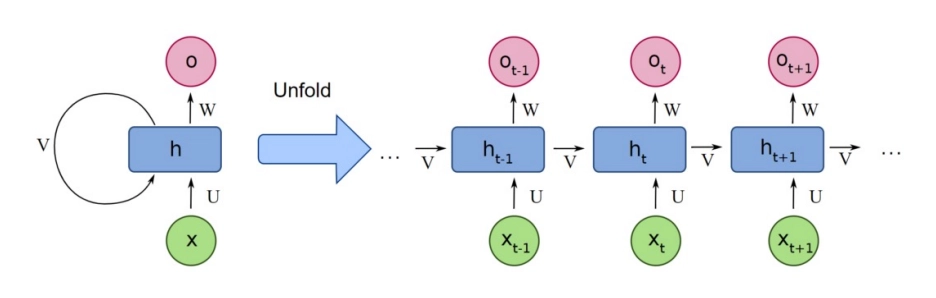
RNN은 데이터의 순서가 중요한 시퀀스 데이터나 시계열 데이터를 처리하기 위해 고안된 신경망. 가장 큰 특징은 신경망 내부에 '순환(Recurrence)' 구조가 있어 과거의 정보가 현재의 결정에 영향을 줄 수 있다.

은닉층 (Hidden Layer): 데이터를 처리하는 '장소'나 '계층' 자체를 의미. 일반적인 신경망과 달리 RNN의 은닉층은 연산 결과를 출력층으로 보낼 뿐만 아니라, 자기 자신에게 다시 전달하는 루프를 가지고 있음.  
은닉 상태 (Hidden State): 은닉층에서 계산되어 저장된 '값'을 의미함. 매 시점($t$)마다 입력값($x_t$)을 받아 새로운 은닉 상태($h_t$)를 계산하며, 이 값은 다음 시점($t+1$)의 입력과 함께 다시 은닉층으로 들어감.  
RNN은 “이전 시점까지의 정보와 현재 시점의 입력이 주어졌을 때, 어떻게 상태(메모리)를 업데이트할 것인가?”라는 하나의 일반적 규칙을 학습

-RNN 한계

기울기 소실

RNN은 이전 정보를 계속 곱하며 전달하는 구조. 이때 역전파(학습) 과정에서 1보다 작은 소수점 값들이 반복해서 곱해지면 결과값이 0에 가까워짐.
문장이 길어질수록 맨 앞부분의 정보가 뒤쪽까지 전달되지 않음. 모델 입장에서 보면 앞에서 무슨 일이 있었는지 잊어버려 가중치 업데이트가 안 되는 현상.

기울기 폭주 
기울기 소실과 반대로, 1보다 큰 값이 반복해서 곱해지면 기울기가 기하급수적으로 커져 무한대가 됨.결과: 가중치가 너무 크게 변해서 학습이 안정되지 못하고,기울기가 일정 수준(문턱값)을 넘지 못하도록 강제로 깎아버리는 '안전장치'를 사용함. 말이 전달될수록 살이 붙어 나중에는 말도 안 되는 유언비어가 되어버리는 상황.

-LSTM과 GRU
| 구분 | LSTM | GRU |
| --- | --- | --- |
| **구조** | 3개 게이트 (입력, 삭제, 출력) 정보를 기억할지 말지(Forget), 새로운 정보를 넣을지(Input), 밖으로 내보낼지(Output)를 각각의 게이트가 엄격하게 관리함 전용 통로(장기 기억)가 있어 정보가 훼손되지 않고 멀리 전달됨. | 2개 게이트 (업데이트, 리셋) LSTM의 Forget 게이트와 Input 게이트를 Update 게이트 하나로 합쳤음. "얼마나 잊고 얼마나 채울지"를 한 번에 결정하기 때문에 계산이 훨씬 가벼움 |
| **복잡도** | 더 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음, ell State 없이 모든 정보를 담음. 정보 전달 방식은 단순하지만, 때로는 LSTM만큼 정교한 제어가 어려울 수 있음 |
| **학습 속도** | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| **메모리 사용량** | 큼 | 작음 |
| **장기 의존성 처리** | 더 강력 | LSTM과 비교해 다소 약함 |
| **연구/사례 축적** | 매우 많음 | 비교적 적음 (최근 등장) |
| **성능** | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |

-Seq2Seq
    한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용
하나의 시퀀스를 입력받아 다른 형태의 시퀀스를 출력하는 모델 구조, 주로 기계 번역, 텍스트 요약, 챗봇처럼 입력과 출력의 길이가 서로 다를 때 아주 유용하게 쓰임
입력 문장이 5개 단어여도 출력은 10개 단어가 될 수 있음. 고정된 크기의 데이터를 다루는 일반적인 신경망보다 유연
기 Seq2Seq는 내부 구조로 RNN이나 LSTM을 사용했음. 덕분에 단어의 순서 정보를 유지하며 번역이 가능

입력 개수와 출력 개수가 같지 않아도 됨. 시퀀스를 압축하여 디코더에게 넘겨줄 문맥 정보를 준비하고, 임베딩된 단어 입력과 은닉 상태가 입력으로 주어녀 t 시점 은닉 상태가 나온다. / 디코더는 압축된 정보 바탕 시퀀스 생성, 컨텍스트 벡터는 디코더의 첫번째 은닉 상태에 사용된다. 

켄텍스트 벡터란: 입력 시퀀스(입력된 문장)의 요약 정보처럼 작동. 
벡터의 차원은 직접 설정할 수 있다. 위의 그림에서는 4차원이지만 실제로 사용할 때는 256, 512, 1024 차원으로 설정한다.


